In [89]:
import numpy as np
import matplotlib.pyplot as plt
import time
import pandas as pd # Para organizar os resultados dos estudos

# Configuração para os gráficos ficarem mais bonitos no notebook
%matplotlib inline
plt.style.use('ggplot')

In [90]:
# --- Parâmetros Físicos e de Simulação (baseado no PDF) ---
L = 1.0                # Comprimento da barra (m)
alpha = 1.0e-4           # Coeficiente de difusão térmica (m^2/s)
T_inicial = 20.0         # Temperatura inicial uniforme (°C)
T_A = 100.0              # Temp. na extremidade x=0 (Dirichlet) (°C)
# q_L = 0 (Neumann) é implementado na função

# --- Parâmetros Numéricos (Caso Base) ---
n_base = 51              # Número de nós no espaço
dt_base = 10.0             # Tamanho do passo de tempo (s)
t_total_base = 500.0       # Tempo total da simulação 1 (s)

In [91]:
def simular_difusao(L, alpha, n, dt, t_total, T_inicial, T_A):
    """
    Resolve a equação do calor 1D com método implícito DIRETO (Inversão de Matriz).
    C.C. Dirichlet em x=0 (T_A) e Neumann (isolado, 2ª ordem) em x=L.
    
    Retorna o vetor de posição (x), o vetor de tempos e o histórico completo
    das temperaturas (matriz T_historico).
    """
    
    start_time = time.time()
    
    # --- 1. Discretização ---
    dx = L / (n - 1)
    x = np.linspace(0, L, n)
    s = (alpha * dt) / (dx**2) # Parâmetro de difusão
    n_steps = int(t_total / dt)
    
    # --- 2. Montagem da Matriz A (constante no tempo) ---
    A = np.zeros((n, n))
    
    # C.C. Dirichlet em x=0 (i=0)
    A[0, 0] = 1.0
    
    # Nós internos (i=1 a n-2)
    for i in range(1, n - 1):
        A[i, i-1] = -s
        A[i, i]   = 1.0 + 2.0 * s
        A[i, i+1] = -s
        
    # C.C. Neumann em x=L (i=n-1) [Aproximação de 2ª Ordem]
    # Equação: -2s*T_{n-2} + (1 + 2s)*T_{n-1} = T_{n-1}^k
    A[n-1, n-2] = -2.0 * s
    A[n-1, n-1] = 1.0 + 2.0 * s
    
    # Inverte a matriz A (só precisa fazer uma vez)
    A_inv = np.linalg.inv(A)
    
    # --- 3. Condição Inicial e Armazenamento ---
    T = np.full(n, T_inicial)
    T[0] = T_A
    
    T_historico = np.zeros((n_steps + 1, n))
    T_historico[0] = T.copy()
    tempos = np.linspace(0, t_total, n_steps + 1)
    
    b = np.zeros(n) # Vetor "lado direito" (T^k)
    
    # --- 4. Loop Temporal ---
    for k in range(n_steps):
        # Monta o vetor b (T^k)
        b[1:] = T[1:]
        b[0] = T_A
        
        # Resolve o sistema A * T^{k+1} = b
        T = A_inv.dot(b)
        
        T_historico[k + 1] = T.copy()
        
    tempo_exec = time.time() - start_time
    
    print(f"Simulação (n={n}, dt={dt}) concluída em {tempo_exec:.4f}s.")
    
    return x, tempos, T_historico

In [92]:
# --- SIMULAÇÃO 1: Caso Base (0 a 500s) ---
print("Iniciando Simulação 1 (Caso Base)...")
plot_cada_s = 100.0 # Intervalo para o gráfico de linhas

x_base, tempos_base, T_hist_base = simular_difusao(
    L, alpha, n_base, dt_base, t_total_base, T_inicial, T_A
)

Iniciando Simulação 1 (Caso Base)...
Simulação (n=51, dt=10.0) concluída em 0.0155s.


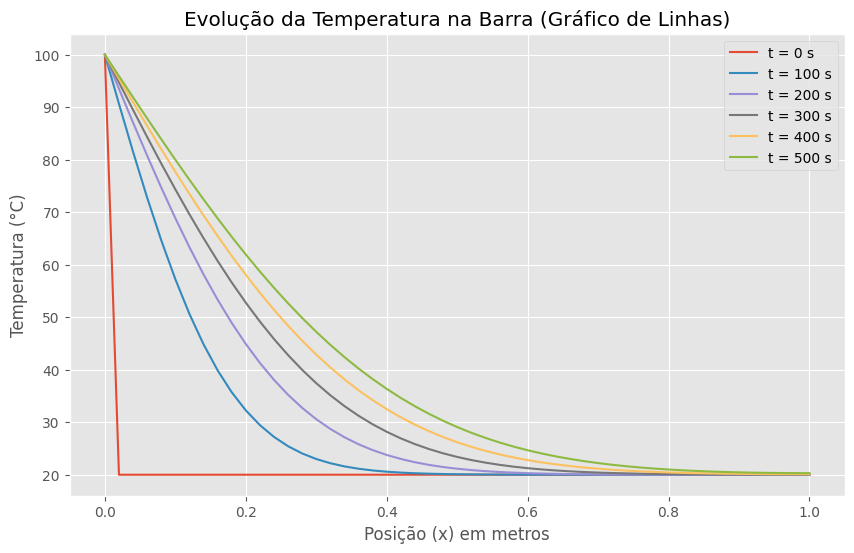

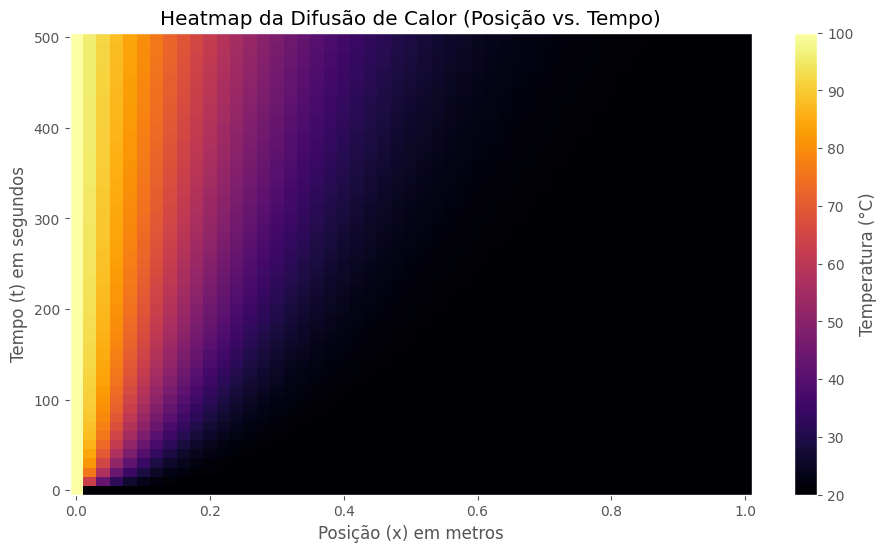

In [93]:
# --- GRÁFICO 1: Evolução da Temperatura (Linhas) ---
plt.figure(figsize=(10, 6))
plt.title('Evolução da Temperatura na Barra (Gráfico de Linhas)')
plt.xlabel('Posição (x) em metros')
plt.ylabel('Temperatura (°C)')

n_steps_base = int(t_total_base / dt_base)

for t in np.arange(0, t_total_base + dt_base, plot_cada_s):
    passo = int(t / dt_base)
    plt.plot(x_base, T_hist_base[passo], label=f't = {t:.0f} s')

plt.legend()
plt.grid(True)
plt.show()

# --- GRÁFICO 2: (EXTRA) Heatmap Posição vs. Tempo ---
plt.figure(figsize=(11, 6))
plt.title('Heatmap da Difusão de Calor (Posição vs. Tempo)')
plt.xlabel('Posição (x) em metros')
plt.ylabel('Tempo (t) em segundos')

plt.pcolormesh(x_base, tempos_base, T_hist_base, shading='auto', cmap='inferno')
plt.colorbar(label='Temperatura (°C)')
plt.show()

In [94]:
temp_porx=pd.DataFrame(T_hist_base, columns=[f"x={x:.2f}m" for x in x_base], index=[f"t={t:.1f}s" for t in tempos_base])    
temp_porx

,x=0.00m,x=0.02m,x=0.04m,x=0.06m,x=0.08m,x=0.10m,x=0.12m,x=0.14m,x=0.16m,x=0.18m,...,x=0.82m,x=0.84m,x=0.86m,x=0.88m,x=0.90m,x=0.92m,x=0.94m,x=0.96m,x=0.98m,x=1.00m
t=0.0s,100.0,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,...,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000
t=10.0s,100.0,62.934003,43.041608,32.365856,26.636446,23.561615,21.911430,21.025817,20.550530,20.295456,...,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000
t=20.0s,100.0,75.879092,56.936220,43.551194,34.640302,28.930952,25.369337,23.190884,21.878459,21.097205,...,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000
t=30.0s,100.0,81.361117,64.915044,51.660499,41.649678,34.442606,29.440197,26.066131,23.842164,22.403679,...,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000
t=40.0s,100.0,84.351312,69.898702,57.439556,47.292032,39.401449,33.494404,29.209042,26.180844,24.088119,...,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000
t=50.0s,100.0,86.265490,73.296651,61.686992,51.776307,43.659333,37.245512,32.332134,28.667992,25.998710,...,20.000001,20.000001,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000
t=60.0s,100.0,87.618492,75.778184,64.930489,55.380193,47.271451,40.607556,35.288478,31.151939,28.008978,...,20.000004,20.000002,20.000001,20.000001,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000
t=70.0s,100.0,88.638485,77.684967,67.494162,58.328826,50.342944,43.585659,38.019615,33.546026,30.030071,...,20.000010,20.000006,20.000004,20.000002,20.000001,20.000001,20.000000,20.000000,20.000000,20.000000
t=80.0s,100.0,89.442479,79.206555,69.579267,60.786021,52.975652,46.218367,40.514166,35.807784,32.006106,...,20.000024,20.000015,20.000009,20.000006,20.000003,20.000002,20.000001,20.000001,20.000001,20.000001
t=90.0s,100.0,90.097156,80.456182,71.315059,62.868254,55.254341,48.551904,42.782882,37.921347,33.905236,...,20.000053,20.000033,20.000021,20.000013,20.000008,20.000005,20.000003,20.000002,20.000002,20.000001


In [95]:
# --- SIMULAÇÃO 2: Validação (Longo Prazo) ---
print("\nIniciando Simulação 2 (Longo Prazo)...")
t_total_longa = 10000.0 # 10.000 segundos

x_long, tempos_long, T_hist_long = simular_difusao(
    L, alpha, n_base, dt_base, t_total_longa, T_inicial, T_A
)

# Extrai a temperatura apenas no último nó (x=L)
T_em_L = T_hist_long[:, -1]


Iniciando Simulação 2 (Longo Prazo)...
Simulação (n=51, dt=10.0) concluída em 0.0069s.


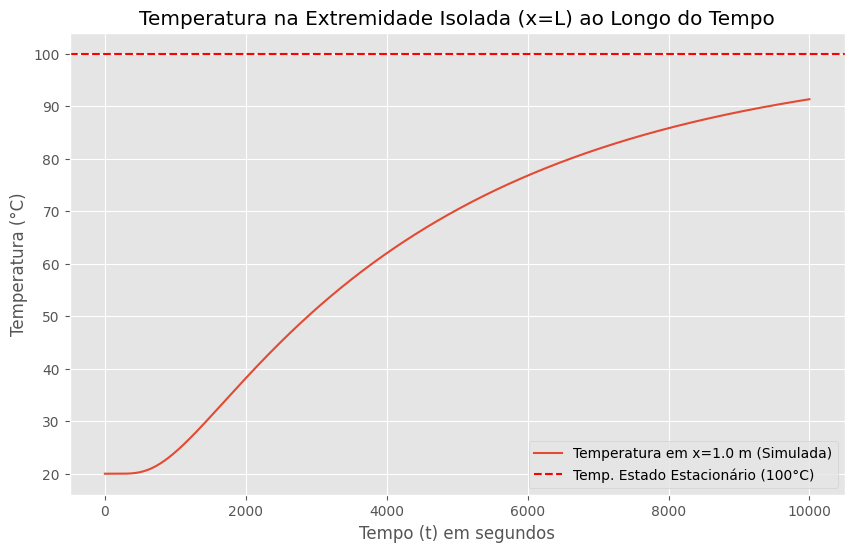

In [96]:
# --- GRÁFICO 3: (EXTRA) Validação do Estado Estacionário ---
plt.figure(figsize=(10, 6))
plt.title('Temperatura na Extremidade Isolada (x=L) ao Longo do Tempo')
plt.xlabel('Tempo (t) em segundos')
plt.ylabel('Temperatura (°C)')

plt.plot(tempos_long, T_em_L, label=f'Temperatura em x={L} m (Simulada)')
plt.axhline(y=100.0, color='r', linestyle='--', label='Temp. Estado Estacionário (100°C)')

plt.legend()
plt.grid(True)
plt.show()

In [97]:
# --- FUNÇÃO AUXILIAR PARA ESTUDOS DE CONVERGÊNCIA ---

def simular_convergencia_direto(L, alpha, n_teste, dt_teste, t_total, T_inicial, T_A):
    """
    Executa uma simulação simplificada e retorna:
    1. Tempo de execução
    2. Temperatura final em x=L
    """
    
    start_time = time.time()
    dx = L / (n_teste - 1)
    n_steps = int(t_total / dt_teste)
    s = (alpha * dt_teste) / (dx**2)
    
    A = np.zeros((n_teste, n_teste))
    A[0, 0] = 1.0
    for i in range(1, n_teste - 1):
        A[i, i-1] = -s
        A[i, i]   = 1.0 + 2.0 * s
        A[i, i+1] = -s
    A[n_teste-1, n_teste-2] = -2.0 * s
    A[n_teste-1, n_teste-1] = 1.0 + 2.0 * s
    
    A_inv = np.linalg.inv(A)
    
    T = np.full(n_teste, T_inicial)
    T[0] = T_A
    b = np.zeros(n_teste)
    
    for k in range(n_steps):
        b[1:] = T[1:]
        b[0] = T_A
        T = A_inv.dot(b)
            
    tempo_exec = time.time() - start_time
    
    return tempo_exec, T[n_teste-1]

In [98]:
# --- ESTUDO 1: CONVERGÊNCIA ESPACIAL (MALHA ESPACIAL, variando 'n') ---
print("Iniciando Estudo de Convergência Espacial (variando N)...")

n_valores = [11, 21, 31, 51, 81, 101, 151]
resultados_espacial = []

for n_teste in n_valores:
    print(f"  Testando N = {n_teste}...")
    tempo_gasto, T_final_L = simular_convergencia_direto(
        L, alpha, n_teste, dt_base, t_total_base, T_inicial, T_A
    )
    
    resultados_espacial.append({
        'N': n_teste,
        'dx': L / (n_teste - 1),
        'T_final_L': T_final_L,
        'Tempo (s)': tempo_gasto,
    })

df_espacial = pd.DataFrame(resultados_espacial)
df_espacial

Iniciando Estudo de Convergência Espacial (variando N)...
  Testando N = 11...
  Testando N = 21...
  Testando N = 31...
  Testando N = 51...
  Testando N = 81...
  Testando N = 101...
  Testando N = 151...


,N,dx,T_final_L,Tempo (s)
0,11,0.100000,20.396431,0.000528
1,21,0.050000,20.322447,0.000468
2,31,0.033333,20.308588,0.000321
3,51,0.020000,20.301470,0.000445
4,81,0.012500,20.299026,0.000804
5,101,0.010000,20.298462,0.030747
6,151,0.006667,20.297905,0.043009


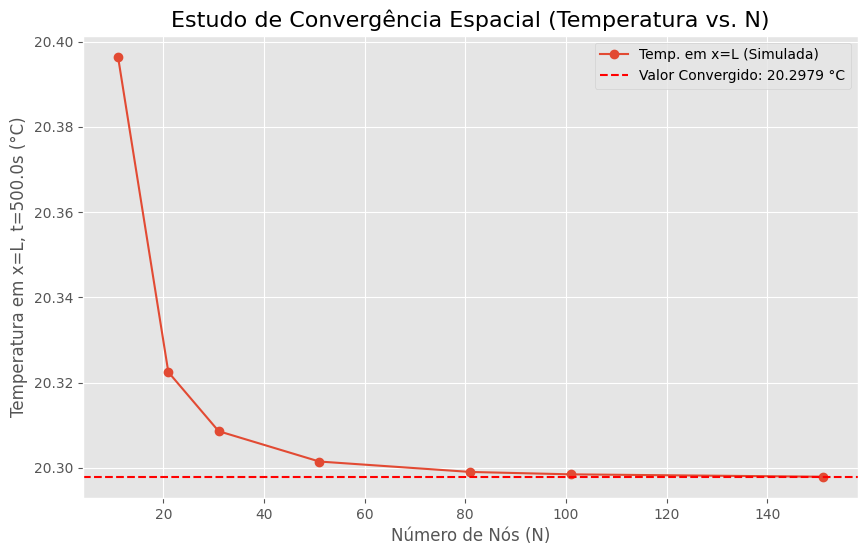

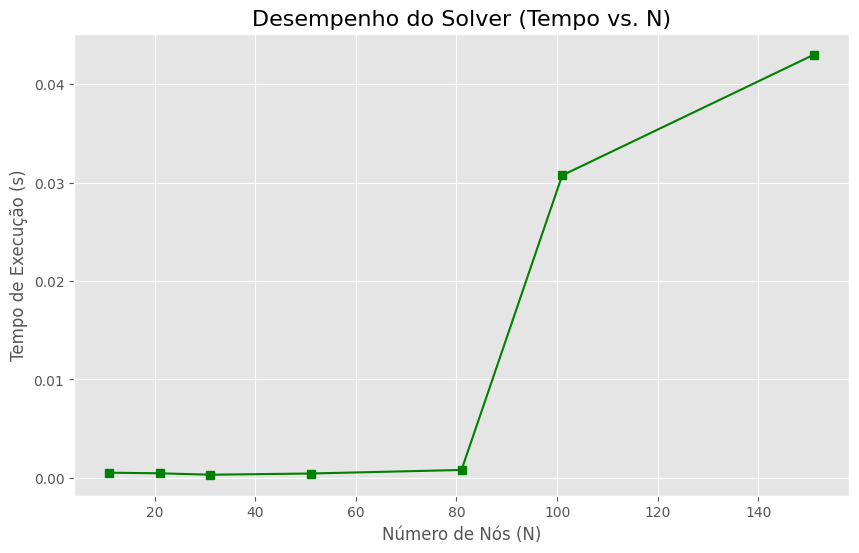

In [99]:
# --- GRÁFICOS: CONVERGÊNCIA ESPACIAL ---

# Gráfico 4: Convergência da Solução (Temperatura vs. N)
plt.figure(figsize=(10, 6))
plt.plot(df_espacial['N'], df_espacial['T_final_L'], 'o-', label='Temp. em x=L (Simulada)')
ref_T = df_espacial['T_final_L'].iloc[-1]
plt.axhline(y=ref_T, color='r', linestyle='--', label=f'Valor Convergido: {ref_T:.4f} °C')
plt.title('Estudo de Convergência Espacial (Temperatura vs. N)', fontsize=16)
plt.xlabel('Número de Nós (N)', fontsize=12)
plt.ylabel(f'Temperatura em x=L, t={t_total_base}s (°C)', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

# Gráfico 5: Custo Computacional (Tempo vs. N)
# (Nota: O custo de inversão de matriz cresce mais rápido que o GS)
plt.figure(figsize=(10, 6))
plt.plot(df_espacial['N'], df_espacial['Tempo (s)'], 's-', color='green')
plt.title('Desempenho do Solver (Tempo vs. N)', fontsize=16)
plt.xlabel('Número de Nós (N)', fontsize=12)
plt.ylabel('Tempo de Execução (s)', fontsize=12)
plt.grid(True)
plt.show()

In [100]:
# --- ESTUDO 2: CONVERGÊNCIA TEMPORAL (PASSO DE TEMPO, variando 'dt') ---
print("\nIniciando Estudo de Convergência Temporal (variando dt)...")
n_fixo = 51 # n Fixo

dt_valores = [20.0, 10.0, 5.0, 2.0, 1.0, 0.5]
resultados_temporal = []

for dt_teste in dt_valores:
    print(f"  Testando dt = {dt_teste}...")
    tempo_gasto, T_final_L = simular_convergencia_direto(
        L, alpha, n_fixo, dt_teste, t_total_base, T_inicial, T_A
    )
    
    resultados_temporal.append({
        'dt': dt_teste,
        'N_passos': int(t_total_base / dt_teste),
        'T_final_L': T_final_L,
        'Tempo (s)': tempo_gasto,
    })

df_temporal = pd.DataFrame(resultados_temporal)
print("\n--- Resultados (Convergência Temporal) ---")
df_temporal


Iniciando Estudo de Convergência Temporal (variando dt)...
  Testando dt = 20.0...
  Testando dt = 10.0...
  Testando dt = 5.0...
  Testando dt = 2.0...
  Testando dt = 1.0...
  Testando dt = 0.5...

--- Resultados (Convergência Temporal) ---


,dt,N_passos,T_final_L,Tempo (s)
0,20.0,25,20.347290,0.000208
1,10.0,50,20.301470,0.000177
2,5.0,100,20.278152,0.000743
3,2.0,250,20.264022,0.000886
4,1.0,500,20.259288,0.001658
5,0.5,1000,20.256916,0.001200


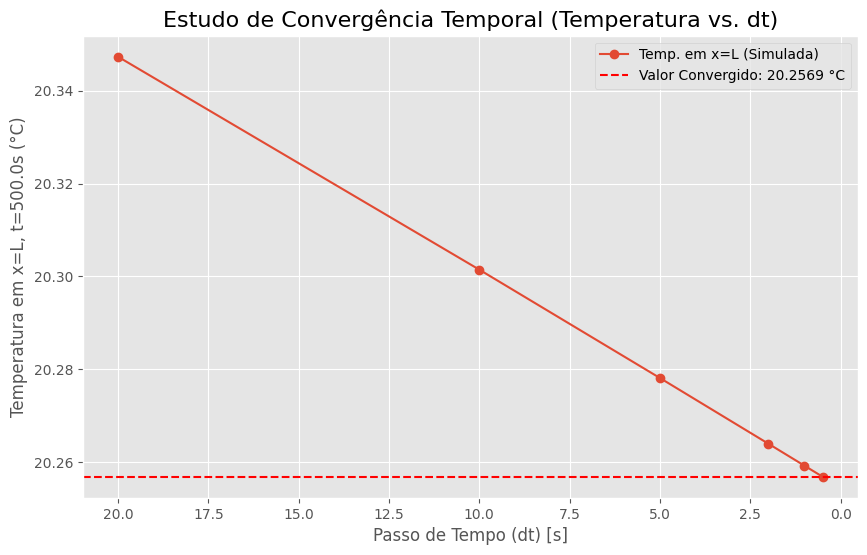

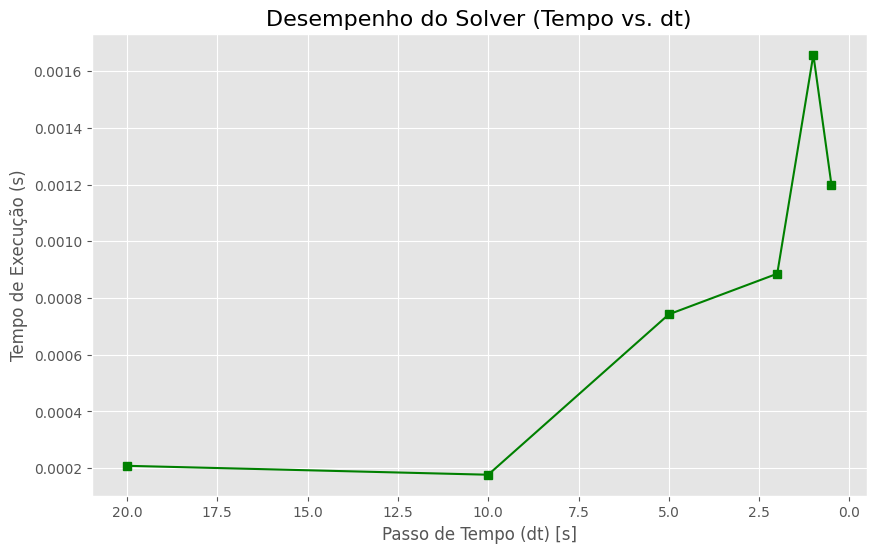

In [101]:
# --- GRÁFICOS: CONVERGÊNCIA TEMPORAL ---

# Gráfico 6: Convergência da Solução (Temperatura vs. dt)
plt.figure(figsize=(10, 6))
plt.plot(df_temporal['dt'], df_temporal['T_final_L'], 'o-', label='Temp. em x=L (Simulada)')
ref_T_dt = df_temporal['T_final_L'].iloc[-1]
plt.axhline(y=ref_T_dt, color='r', linestyle='--', label=f'Valor Convergido: {ref_T_dt:.4f} °C')
plt.title('Estudo de Convergência Temporal (Temperatura vs. dt)', fontsize=16)
plt.xlabel('Passo de Tempo (dt) [s]', fontsize=12)
plt.ylabel(f'Temperatura em x=L, t={t_total_base}s (°C)', fontsize=12)
plt.legend()
plt.grid(True)
plt.gca().invert_xaxis() 
plt.show()

# Gráfico 7: Custo Computacional (Tempo vs. dt)
plt.figure(figsize=(10, 6))
plt.plot(df_temporal['dt'], df_temporal['Tempo (s)'], 's-', color='green')
plt.title('Desempenho do Solver (Tempo vs. dt)', fontsize=16)
plt.xlabel('Passo de Tempo (dt) [s]', fontsize=12)
plt.ylabel('Tempo de Execução (s)', fontsize=12)
plt.grid(True)
plt.gca().invert_xaxis()
plt.show()

In [102]:
# --- ESTUDO 3 (EXTRA): ANÁLISE DE SENSIBILIDADE FÍSICA (variando 'alpha') ---
print("\nIniciando Estudo de Sensibilidade (variando alpha)...")

# Valores de alpha para testar (m^2/s)
alpha_valores = {
    'Material Lento (ex: Madeira)': 5.0e-6,
    'Material Base (do PDF)': 1.0e-4,
    'Material Rápido (ex: Cobre)': 1.0e-3
}

perfis_finais_alpha = {}
evolucao_ponto_L_alpha = {}

for nome_material, alpha_teste in alpha_valores.items():
    print(f"  Simulando: {nome_material} (alpha={alpha_teste})...")
    
    # Roda a simulação principal completa para obter o histórico
    x_alpha, tempos_alpha, T_hist_alpha = simular_difusao_direto(
        L, alpha_teste, n_base, dt_base, t_total_base, T_inicial, T_A
    )
    
    # Guarda o perfil final (T vs x) e a evolução (T vs t)
    perfis_finais_alpha[nome_material] = T_hist_alpha[-1] # Pega o último perfil de T
    evolucao_ponto_L_alpha[nome_material] = T_hist_alpha[:, -1] # Pega a coluna de x=L

print("Estudo de Sensibilidade concluído")

dataframes = pd.DataFrame({
    'Material': list(alpha_valores.keys()),
    'Alpha (m²/s)': list(alpha_valores.values())
})
dataframes


Iniciando Estudo de Sensibilidade (variando alpha)...
  Simulando: Material Lento (ex: Madeira) (alpha=5e-06)...
Simulação (n=51, dt=10.0) concluída em 0.0010s.
  Simulando: Material Base (do PDF) (alpha=0.0001)...
Simulação (n=51, dt=10.0) concluída em 0.0004s.
  Simulando: Material Rápido (ex: Cobre) (alpha=0.001)...
Simulação (n=51, dt=10.0) concluída em 0.0002s.
Estudo de Sensibilidade concluído


,Material,Alpha (m²/s)
0,Material Lento (ex: Madeira),0.000005
1,Material Base (do PDF),0.000100
2,Material Rápido (ex: Cobre),0.001000


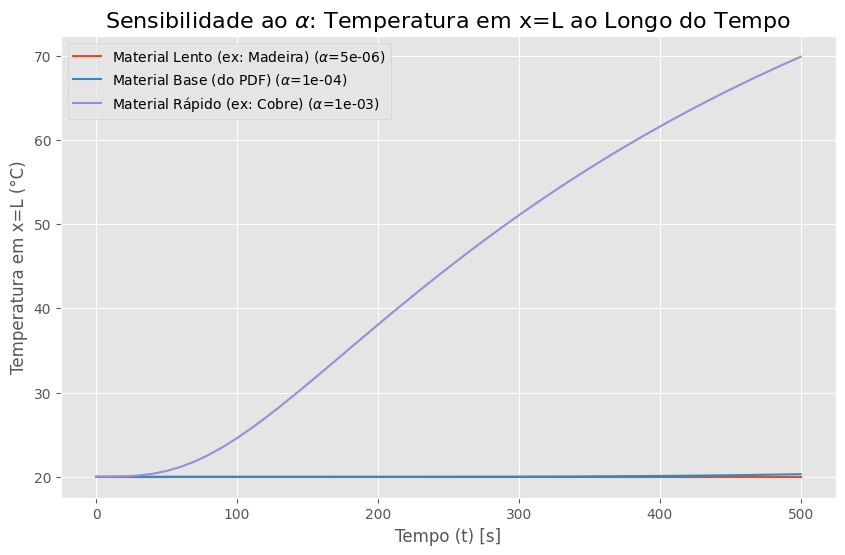

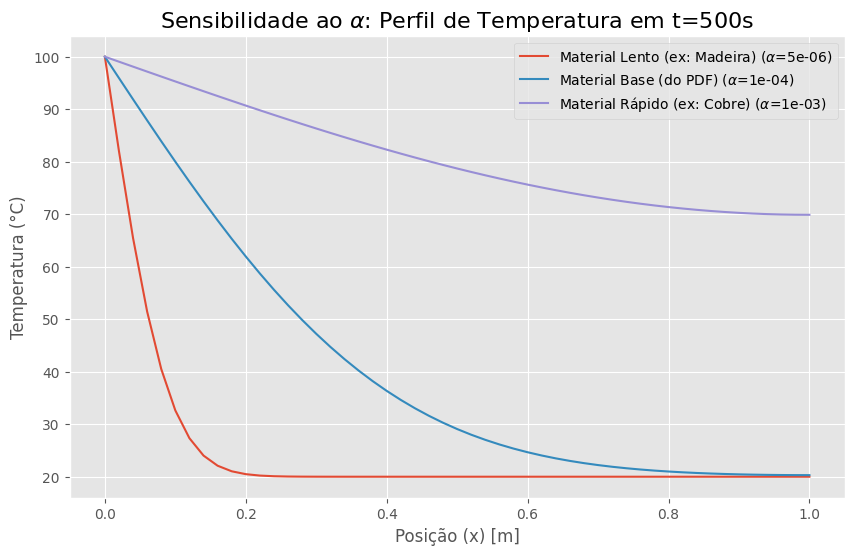

In [103]:
# --- GRÁFICOS: ANÁLISE DE SENSIBILIDADE (vs. 'alpha') ---

# Gráfico 8: Evolução da Temperatura em x=L para diferentes materiais
plt.figure(figsize=(10, 6))
plt.title('Sensibilidade ao $\\alpha$: Temperatura em x=L ao Longo do Tempo', fontsize=16)
for nome_material, evolucao in evolucao_ponto_L_alpha.items():
    plt.plot(tempos_base, evolucao, label=f"{nome_material} ($\\alpha$={alpha_valores[nome_material]:.0e})")
plt.xlabel('Tempo (t) [s]', fontsize=12)
plt.ylabel('Temperatura em x=L (°C)', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

# Gráfico 9: Perfil Final de Temperatura para diferentes materiais
plt.figure(figsize=(10, 6))
plt.title('Sensibilidade ao $\\alpha$: Perfil de Temperatura em t=500s', fontsize=16)
for nome_material, perfil in perfis_finais_alpha.items():
    plt.plot(x_base, perfil, label=f"{nome_material} ($\\alpha$={alpha_valores[nome_material]:.0e})")
plt.xlabel('Posição (x) [m]', fontsize=12)
plt.ylabel('Temperatura (°C)', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()